# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Path](#clean-path)
  * [Clean Function](#clean-function)
* [1. Clean Standard ACS Datasets](#1.-clean-standard-acs-datasets)
* [2. Clean Poverty Data](#2.-clean-poverty-data)
* [3. Clean Income Data](#3.-clean-income-data)
* [4. Clean Active Permits](#4.-clean-active-permits)
* [5. GeoDataFrames](#5.-geodataframes)
    * [Permits](#permits)
    * [Tracts](#tracts)
* [6. Merge Prep](#6.-merge-prep)
* [7. Merging and Polishing](#7.-merging-and-polishing)
* [8. Need Index](#8.-need-index)
* [9. Visualizations](#9.-visualizations)
* [TOC Generator](#toc-generator)

## Imports

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

## Clean Path

In [2]:
BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'data' / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Clean Function

In [3]:
def clean_standard_acs_data(
    file_name: str, 
    output_name: str, 
    value_col_name: str,
    raw_dir: Path,
    processed_dir: Path,
    numeric_cols: list = None
) -> pd.DataFrame:
    """
    Cleans and standardizes American Community Survey (ACS) datasets.
    
    Reads a raw ACS CSV file, removes margin-of-error columns, transposes 
    the dataset, standardizes header names, extracts numeric Census Tract 
    identifiers, converts optional list of columns to numeric, and exports 
    the cleaned data to the processed directory.

    Args:
        file_name (str): The filename of the raw CSV to read.
        output_name (str): The desired filename for the cleaned CSV output.
        value_col_name (str): The standardized name to assign to the target 
            data column (e.g., 'MEDIAN_GROSS_RENT' or 'TOTAL').
        raw_dir (Path): The directory path containing the raw data files.
        processed_dir (Path): The directory path where cleaned data is saved.

    Returns:
        pd.DataFrame: The cleaned dataset as a pandas DataFrame.
    """
    input_path = raw_dir / file_name
    output_path = processed_dir / output_name

    df = pd.read_csv(input_path)

    # Drop Margin of Error columns
    error_columns = df.columns[df.columns.str.contains('Margin of Error', na=False)]
    df = df.drop(columns=error_columns)

    # Transpose and reset structure
    df = df.transpose().reset_index()
    df = df.rename(columns=df.iloc[0]).drop(df.index[0])

    # Clean column names
    df.columns = df.columns.str.strip()
    
    # Standardize important columns
    target_renames = {
        'Total:': 'TOTAL',
        'Median gross rent': value_col_name,
        'Median value': value_col_name,
        'Median value (dollars)': value_col_name,
        df.columns[0]: 'TRACT'
    }
    df = df.rename(columns=target_renames)

    # Extract tract number
    df['TRACT'] = df['TRACT'].str.extract(r'Census Tract ([\d.]+)')

    # Convert selected columns to numeric
    if numeric_cols:
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(
                    df[col].astype(str).str.replace(",", "", regex=False),
                    errors="coerce"
                )

    df.to_csv(output_path, index=True)
    print(f"Successfully processed and saved {output_name}")

    return df

# 1. Clean Standard ACS Datasets

In [4]:
print("Processing standard ACS datasets...")

# Housing Age - Use 1980 and before as older units
pre_1980_cols = [
    "Built 1970 to 1979",
    "Built 1960 to 1969",
    "Built 1950 to 1959",
    "Built 1940 to 1949",
    "Built 1939 or earlier"
]

df_housing_age = clean_standard_acs_data(
    file_name='acs_2024_jefferson_housing_age_by_tract_b25034.csv',
    output_name='housing_age_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=["TOTAL"] + pre_1980_cols
)

df_rent = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_gross_rent_by_tract_b25064.csv',
    output_name='rent_clean.csv',
    value_col_name='GROSS_RENT_USD',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['GROSS_RENT_USD']
)

df_home_value = clean_standard_acs_data(
    file_name='acs_2024_jefferson_median_home_value_by_tract_b25077.csv',
    output_name='home_value_clean.csv',
    value_col_name='HOME_VALUE_USD',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['HOME_VALUE_USD']
)

df_rent_burden = clean_standard_acs_data(
    file_name='acs_2024_jefferson_rent_burden_by_tract_b25070.csv',
    output_name='rent_burden_clean.csv',
    value_col_name='TOTAL',
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
    numeric_cols=['TOTAL', '50.0 percent or more']
)

Processing standard ACS datasets...
Successfully processed and saved housing_age_clean.csv
Successfully processed and saved rent_clean.csv
Successfully processed and saved home_value_clean.csv
Successfully processed and saved rent_burden_clean.csv


# 2. Clean Poverty Data

In [5]:
print("Processing Poverty dataset...")
df_poverty = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_poverty_by_tract_s1701.csv')
df_poverty = df_poverty[["GEO_ID", "NAME",
                         "S1701_C01_001E", "S1701_C02_001E", "S1701_C03_001E"]]
df_poverty = df_poverty.drop(index=0)

df_poverty = df_poverty.rename(columns={
    "GEO_ID": "GEOID",
    "NAME": "TRACT",
    "S1701_C01_001E": "POPULATION",
    "S1701_C02_001E": "BELOW_POVERTY",
    "S1701_C03_001E": "POVERTY_RATE_PCT"
})
# Strip first 11 digits
df_poverty["GEOID"] = df_poverty["GEOID"].str[-11:]

df_poverty['TRACT'] = df_poverty['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Convert to numeric and remove commas to standardize
df_poverty["POVERTY_RATE_PCT"] = pd.to_numeric(
    df_poverty["POVERTY_RATE_PCT"].astype(str).str.replace(",", "", regex=False), 
    errors="coerce"
)

df_poverty.to_csv(PROCESSED_DIR / 'poverty_rate_clean.csv', index=False)
print("Successfully processed and saved poverty_rate_clean.csv")

Processing Poverty dataset...
Successfully processed and saved poverty_rate_clean.csv


# 3. Clean Income Data

In [6]:
print("Processing Income dataset...")
df_income = pd.read_csv(
    RAW_DIR / 'acs_2024_jefferson_household_income_by_tract_b19013.csv')
df_income = df_income.rename(columns={
    "Label (Grouping)": "TRACT",
    "Median household income in the past 12 months (in 2024 inflation-adjusted dollars)": "HOUSEHOLD_INCOME_USD"
})

# Shift values up one to put on same row as TRACT
df_income['HOUSEHOLD_INCOME_USD'] = df_income['HOUSEHOLD_INCOME_USD'].shift(-1)
df_income = df_income.drop(df_income[df_income['TRACT'].str.contains(
    'Estimate|Margin of Error', na=False)].index)
df_income['TRACT'] = df_income['TRACT'].str.extract(r'Census Tract ([\d.]+)')

# Convert to numeric and remove commas to standardize
df_income["HOUSEHOLD_INCOME_USD"] = pd.to_numeric(
    df_income["HOUSEHOLD_INCOME_USD"].astype(str).str.replace(",", "", regex=False), 
    errors="coerce"
)

df_income.to_csv(PROCESSED_DIR / 'income_clean.csv', index=False)
print("Successfully processed and saved income_clean.csv")

Processing Income dataset...
Successfully processed and saved income_clean.csv


# 4. Clean Active Permits

In [7]:
print("Processing Active Permits dataset...")
df_permits = pd.read_csv(
    RAW_DIR / 'louisville_active_construction_permits.csv')

df_permits["ZIPCODE"] = df_permits["ZIPCODE"].astype(str).str.split("-").str[0]
df_permits = df_permits[['ISSUE_DATE', 'ADDRESS', 'CITY',
                         'ZIPCODE', 'LATITUDE', 'LONGITUDE', 'DISTRICT', 'NEIGHBORHOOD']]

# Convert to datetime and filter for 2024 efficiently
df_permits['ISSUE_DATE'] = pd.to_datetime(
    df_permits['ISSUE_DATE'], errors='coerce')
df_permits = df_permits[df_permits['ISSUE_DATE'].dt.year == 2024]

df_permits.to_csv(PROCESSED_DIR / 'permits_clean.csv', index=False)
print("Successfully processed and saved permits_2024_clean.csv")
print("All files processed successfully!")

Processing Active Permits dataset...
Successfully processed and saved permits_2024_clean.csv
All files processed successfully!


# 5. GeoDataFrames

In [8]:
# Using geopandas to establish neighborhood boundaries
gdf_neighborhoods = gpd.read_file( RAW_DIR / 'louisville_neighborhoods.shp')

# Convert to latitude and logitude - 4326 is commonly used for GPS-like mapping using degrees
gdf_neighborhoods = gdf_neighborhoods.to_crs("EPSG:4326")

### Permits

In [10]:
# Convert to a GeoDataFrame
gdf_permits = gpd.GeoDataFrame(df_permits, geometry = gpd.points_from_xy(df_permits["LONGITUDE"], df_permits["LATITUDE"]), crs = "EPSG:4326")

# Spatial join to fill in missing Neighborhood data
# To note, this will only will in ~33% of the missing data, since ~66% of 2024 permits happened outside the defined neighborhood boundaries from the shapefile.
gdf_result_perm_neig = gpd.sjoin(gdf_permits, gdf_neighborhoods, how="left", predicate="intersects")

# Fill in the missing values
gdf_result_perm_neig["NEIGHBORHOOD"] = gdf_result_perm_neig["NEIGHBORHOOD"].fillna(gdf_result_perm_neig["NH_NAME"])

# Output clean file
gdf_result_perm_neig.to_csv(PROCESSED_DIR / "permits_neighborhoods_clean.csv", index = True)

### Tracts

In [11]:
# Load shapefile (geometry is polygon)
gdf_tracts = gpd.read_file(RAW_DIR / "tl_2023_21_tract.shp")

# Filter to Jefferson County (111) using Federal Information Processing Standard (FIPS)
gdf_tracts = gdf_tracts[gdf_tracts["COUNTYFP"] == "111"]

# Convert to ESPG:4326
gdf_tracts = gdf_tracts.to_crs("EPSG:4326")

#---------------------------------------------------------------------------------------------

# Spatial join with our permit data
# Note: this changes the geometry from polygon to point
gdf_permit_tracts = gpd.sjoin(gdf_permits, gdf_tracts, how = "left", predicate = "intersects")

# 6. Merge Prep

In [12]:
# Permits - Pull out GEOID and add a count column for plotting
permits_tract_count = (gdf_permit_tracts.groupby("GEOID").size().reset_index(name = "PERMIT_COUNT"))

#----------------------------------------------------------------------------------------------------#

# Housing age - Add older unit column that sums the pre-1980 builds
df_housing_age["OLDER_UNITS"] = df_housing_age[pre_1980_cols].sum(axis=1)

# Calculate percentage
df_housing_age["OLDER_HOUSING_PCT"] = (
    df_housing_age["OLDER_UNITS"] / df_housing_age["TOTAL"]
) * 100

#----------------------------------------------------------------------------------------------------#

# Rent burden
df_rent_burden["RENT_BURDEN_PCT"] = (df_rent_burden["50.0 percent or more"] / df_rent_burden["TOTAL"]) * 100

# 7. Merging and Polishing

In [14]:
print("Merging all DataFrames...")

df_merged = pd.merge(permits_tract_count, df_poverty[["GEOID", "TRACT", "POVERTY_RATE_PCT"]], on = "GEOID", how = "right")
df_merged = pd.merge(df_merged, df_housing_age[["TRACT", "OLDER_HOUSING_PCT"]], on = "TRACT", how = "left")
df_merged = pd.merge(df_merged, df_rent_burden[["TRACT", "RENT_BURDEN_PCT"]], on = "TRACT", how ="left")
df_merged = pd.merge(df_merged, df_home_value[["TRACT", "HOME_VALUE_USD"]], on = "TRACT", how = "left")
df_merged = pd.merge(df_merged, df_income[["TRACT", "HOUSEHOLD_INCOME_USD"]], on = "TRACT", how = "left")
df_merged = pd.merge(df_merged, df_rent[["TRACT", "GROSS_RENT_USD"]], on = "TRACT", how = "left")

# Order the columns a bit more logically
df_merged = df_merged[["GEOID", "TRACT", "HOUSEHOLD_INCOME_USD", "HOME_VALUE_USD", "GROSS_RENT_USD", "POVERTY_RATE_PCT", 
                 "RENT_BURDEN_PCT", "OLDER_HOUSING_PCT", "PERMIT_COUNT"]]

# Replace zeros with NaN
df_merged = df_merged.replace(0, np.nan)

# Replace blank strings and strings that are just spaces with NaN (just in case)
df_merged.replace(r'^\s*$', np.nan, regex=True, inplace=True)

df_merged.to_csv(PROCESSED_DIR / 'merged.csv', index=False)
print("Successfully processed and saved merged.csv!")

Merging all DataFrames...
Successfully processed and saved merged.csv!


# 8. Need Index

In [15]:
print("Creating Need Index...")

# Using a copy of merged
df_plot = df_merged.copy()

need_cols = [
    "HOUSEHOLD_INCOME_USD",
    "HOME_VALUE_USD",
    "GROSS_RENT_USD",
    "POVERTY_RATE_PCT",
    "RENT_BURDEN_PCT",
    "OLDER_HOUSING_PCT"
]

# Min-max scaling
for col in need_cols:
    df_plot[col + "_scaled"] = (
        (df_plot[col] - df_plot[col].min()) /
        (df_plot[col].max() - df_plot[col].min())
    )

# Reverse columns where lower values indicate more need
reverse_cols = [
    "HOUSEHOLD_INCOME_USD",
    "HOME_VALUE_USD"
]

for col in reverse_cols:
    df_plot[col + "_scaled"] = 1 - df_plot[col + "_scaled"]

# Build need index
scaled_cols = [col + "_scaled" for col in need_cols]

df_plot["NEED_INDEX"] = df_plot[scaled_cols].mean(axis=1)

df_plot.to_csv(PROCESSED_DIR / 'plot.csv', index=False)

print("Successfully processed and saved plot.csv!")

Creating Need Index...
Successfully processed and saved plot.csv!


# 9. Visualizations

In [16]:
# Geometry = polygon
map_df = gdf_tracts.merge(df_plot, on = "GEOID", how = "left")

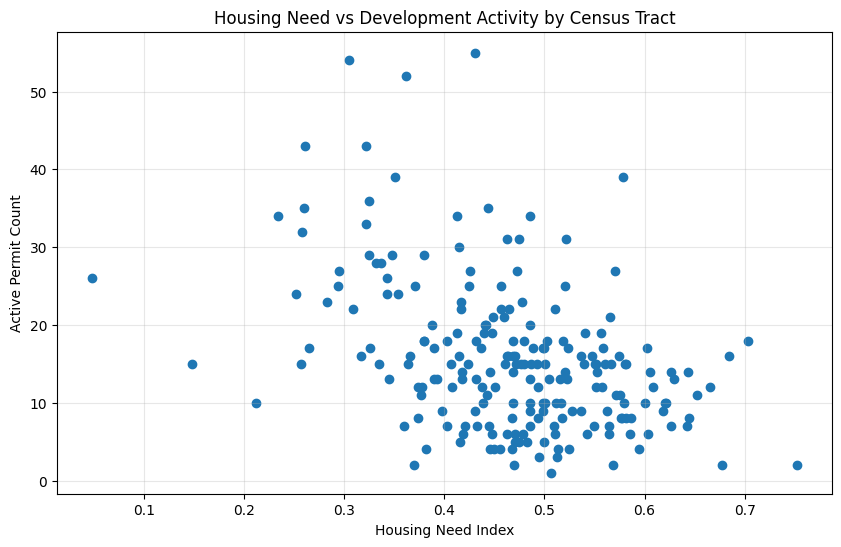

In [17]:
# Compare permit count vs need index
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["NEED_INDEX"], df_plot["PERMIT_COUNT"])
plt.xlabel("Housing Need Index")
plt.ylabel("Active Permit Count")
plt.title("Housing Need vs Development Activity by Census Tract")
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / "need_permits_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

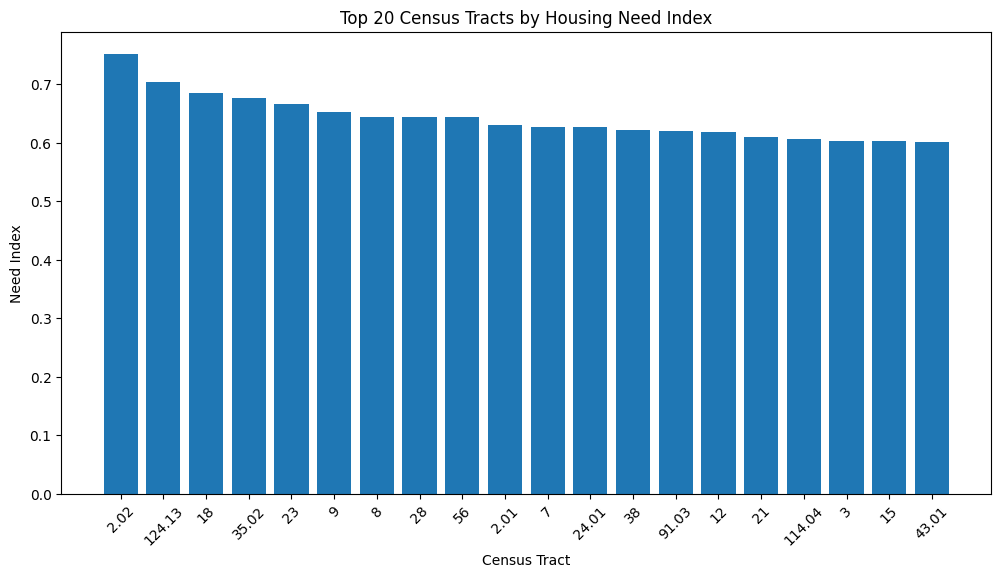

In [18]:
top_tracts = (
    map_df[['TRACT', 'NEED_INDEX']]
    .sort_values(by='NEED_INDEX', ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_tracts['TRACT'].astype(str),
    top_tracts['NEED_INDEX']
)

plt.xticks(rotation=45)

plt.title('Top 20 Census Tracts by Housing Need Index')
plt.xlabel('Census Tract')
plt.ylabel('Need Index')

plt.savefig(FIGURES_DIR / "highest_need_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

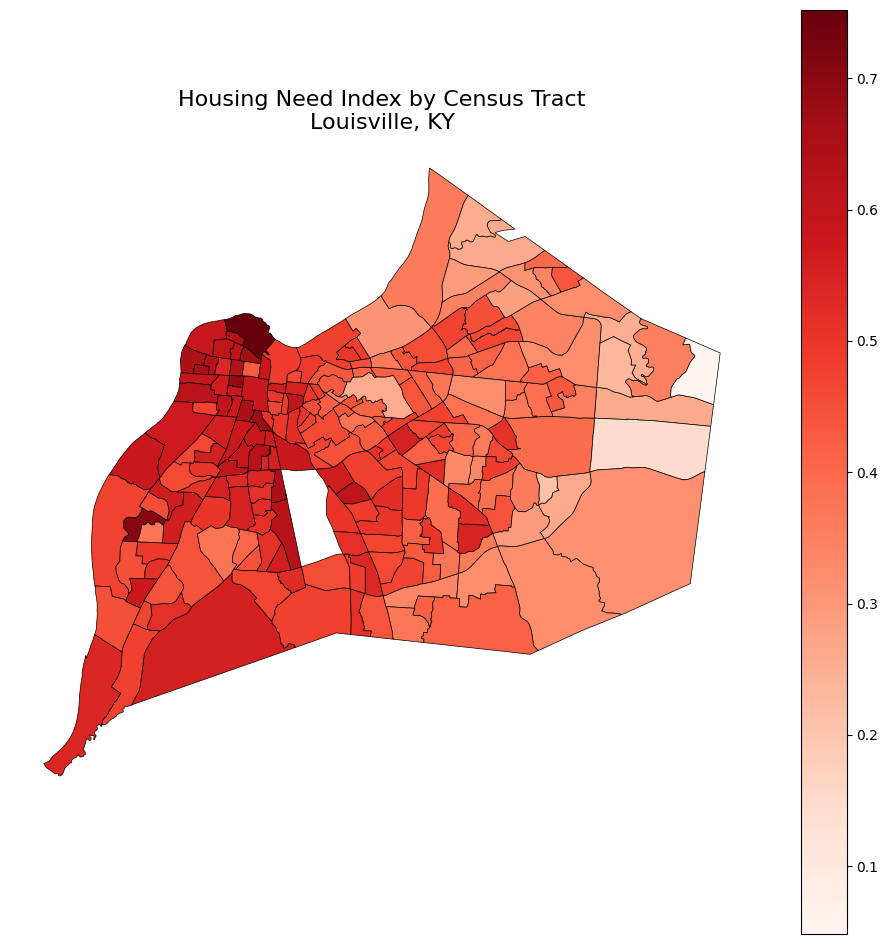

In [19]:
# Housing Need Choropleth 

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Housing Need Index by Census Tract\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

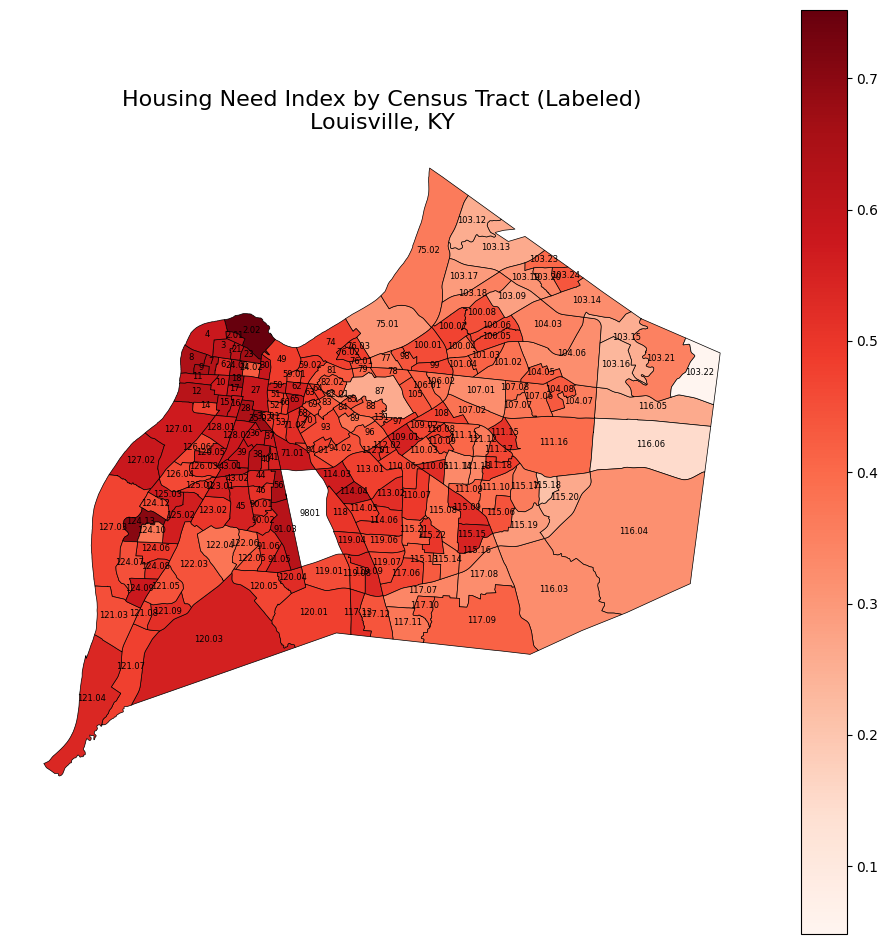

In [20]:
# Housing Need Choropleth 

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Add tract labels
for idx, row in map_df.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=6,
        ha="center"
    )

ax.set_title(
    "Housing Need Index by Census Tract (Labeled)\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth_with_tract_labels.png", dpi=300, bbox_inches="tight")

plt.show()

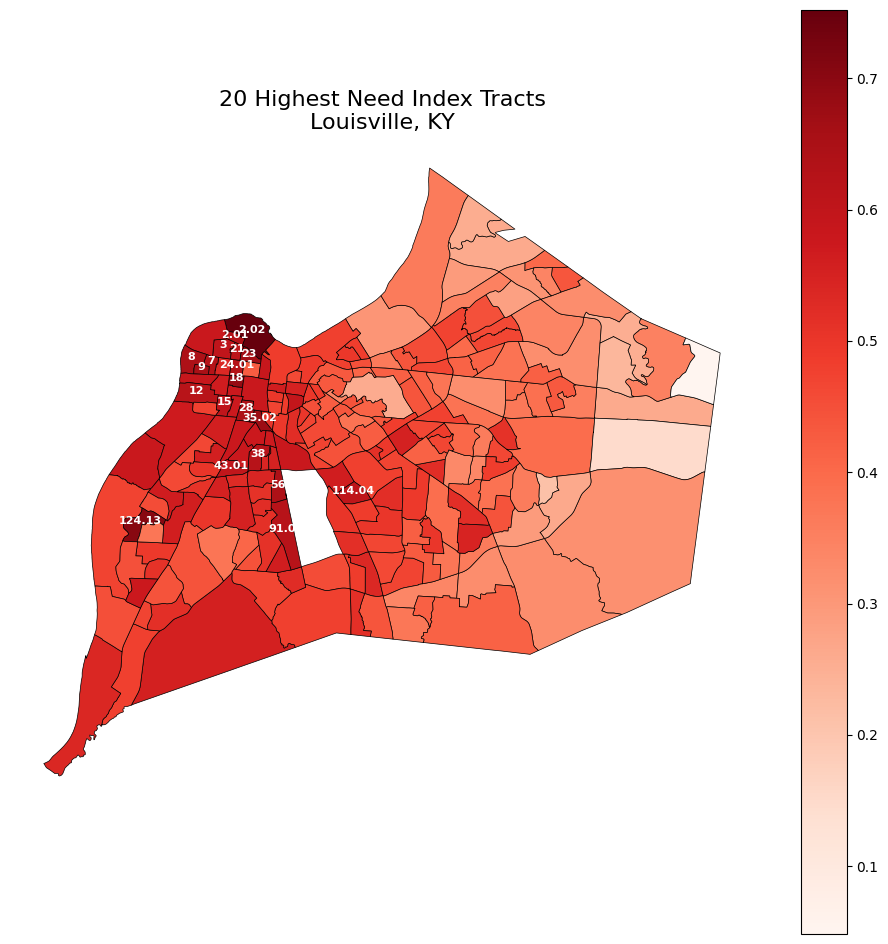

In [21]:
# Housing Need Choropleth 

top_tracts = map_df.nlargest(20, "NEED_INDEX")

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_tracts.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=8,
        fontweight="bold",
        color='white',
        ha="center"
    )

ax.set_title(
    "20 Highest Need Index Tracts\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_need_choropleth_with_labels.png", dpi=300, bbox_inches="tight")

plt.show()

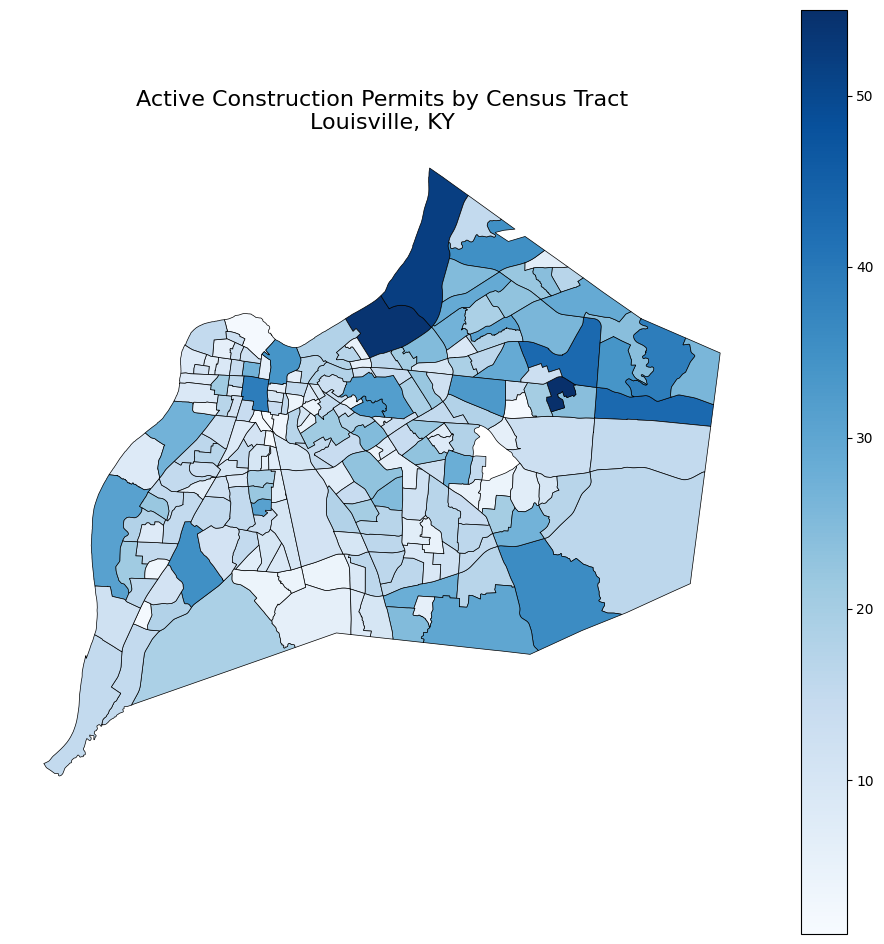

In [22]:
# Permit Choropleth

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Active Construction Permits by Census Tract\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "permit_count_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

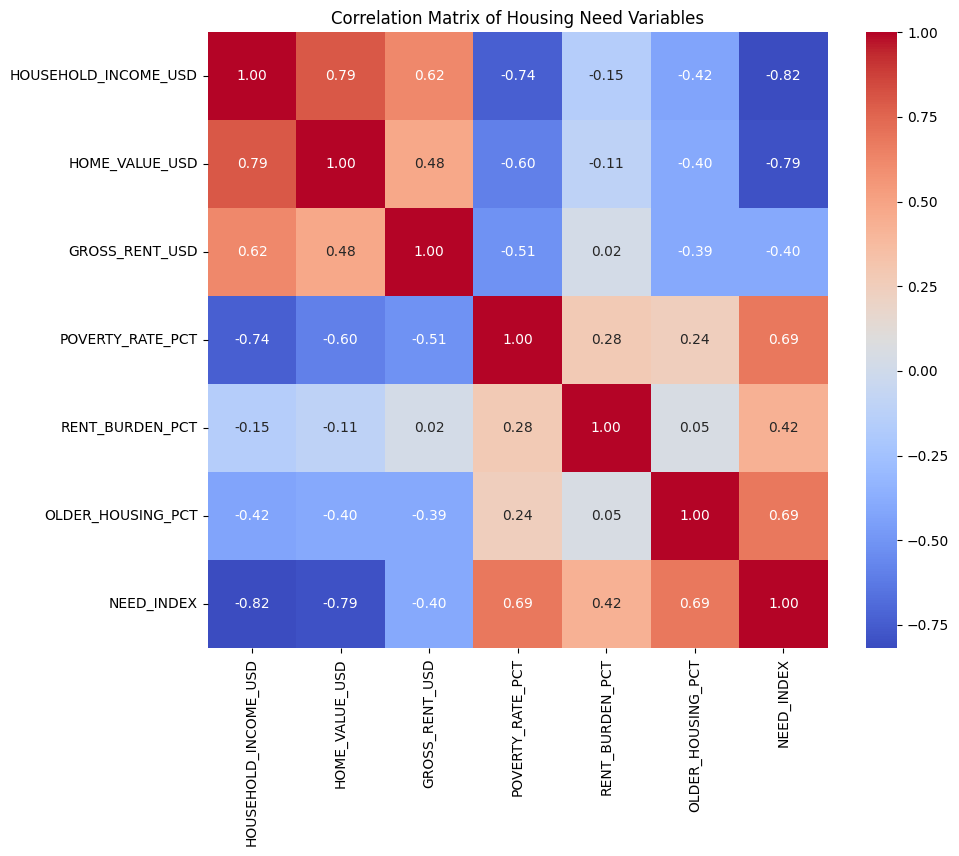

In [23]:
corr_cols = [
    'HOUSEHOLD_INCOME_USD',
    'HOME_VALUE_USD',
    'GROSS_RENT_USD',
    'POVERTY_RATE_PCT',
    'RENT_BURDEN_PCT',
    'OLDER_HOUSING_PCT',
    'NEED_INDEX'
]

corr_matrix = map_df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Housing Need Variables')

plt.savefig(FIGURES_DIR / "need_correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# TOC Generator 

Do not delete code. It will read your markdown and generate a TOC we can put in the notebook for easy navigation. 

In [25]:
import json
import os


def generate_toc_from_notebook(notebook_path):
    """
    Parses a local .ipynb file and generates Markdown for a Table of Contents.
    """
    if not os.path.isfile(notebook_path):
        print(f"❌ Error: File not found at '{notebook_path}'")
        return

    with open(notebook_path, 'r', encoding='utf-8') as f:
        notebook = json.load(f)

    toc_markdown = "# **Table of Contents**\n"
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') == 'markdown':
            for line in cell.get('source', []):
                if line.strip().startswith('#'):
                    level = line.count('#')
                    title = line.strip('#').strip()
                    link = title.lower().replace(' ', '-').strip('-.()')
                    indent = '  ' * (level - 1)
                    toc_markdown += f"{indent}* [{title}](#{link})\n"

    print("\n--- ✅ Copy the Markdown below and paste"
          "it into a new markdown cell ---\n")
    print(toc_markdown)


if __name__ == "__main__":
    # Example usage
    notebook_path = 'curtis.ipynb'  # Replace with your notebook path
    generate_toc_from_notebook(notebook_path)


--- ✅ Copy the Markdown below and pasteit into a new markdown cell ---

# **Table of Contents**
* [**Table of Contents**](#**table-of-contents**)
  * [Imports](#imports)
  * [Clean Path](#clean-path)
  * [Clean Function](#clean-function)
* [1. Clean Standard ACS Datasets](#1.-clean-standard-acs-datasets)
* [2. Clean Poverty Data](#2.-clean-poverty-data)
* [3. Clean Income Data](#3.-clean-income-data)
* [4. Clean Active Permits](#4.-clean-active-permits)
* [5. GeoDataFrames](#5.-geodataframes)
    * [Permits](#permits)
    * [Tracts](#tracts)
* [6. Merge Prep](#6.-merge-prep)
* [7. Merging and Polishing](#7.-merging-and-polishing)
* [8. Need Index](#8.-need-index)
* [9. Visualizations](#9.-visualizations)
* [TOC Generator](#toc-generator)

